In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('/Users/caleb/Desktop/ds-studio-ii/DataSets/SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv')

In [3]:
df.shape

(1016, 8)

In [4]:
df.head(15)

,2017 NAICS Code,2017 NAICS Title,GHG,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Reference USEEIO Code
0,111110,Soybean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
1,111120,Oilseed (except Soybean) Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
2,111130,Dry Pea and Bean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
3,111140,Wheat Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
4,111150,Corn Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
5,111160,Rice Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
6,111191,Oilseed and Grain Combination Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
7,111199,All Other Grain Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
8,111211,Potato Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200
9,111219,Other Vegetable (except Potato) and Melon Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200


Clean up column names, focusing on Title and Total Emission Factor with Margin.

In [5]:
target_col = 'Supply Chain Emission Factors with Margins'
name_col = '2017 NAICS Title'

In [6]:
top_10_emitters = df.sort_values(by=target_col, ascending=False).head(10)


In [7]:
# Standardize column names makes them easier to work with
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

#  Treat NAICS codes as strings to prevent dropping leading zeros
df['2017_naics_code'] = df['2017_naics_code'].astype(str).str.zfill(6)

#Clean up the industry titles to remove any extra whitespace
df['2017_naics_title'] = df['2017_naics_title'].str.strip()

# Drop the columns that are not needed
cols_to_drop = [
    'Supply Chain Emission Factors without Margins',
    'Margins of Supply Chain Emission Factors',
    'Reference USEEIO Code',
    'ghg'
]
df = df.drop(columns=[col.lower().replace(' ', '_') for col in cols_to_drop])

In [8]:
df.head()

,2017_naics_code,2017_naics_title,unit,supply_chain_emission_factors_with_margins
0,111110,Soybean Farming,"kg CO2e/2022 USD, purchaser price",0.532
1,111120,Oilseed (except Soybean) Farming,"kg CO2e/2022 USD, purchaser price",0.532
2,111130,Dry Pea and Bean Farming,"kg CO2e/2022 USD, purchaser price",0.848
3,111140,Wheat Farming,"kg CO2e/2022 USD, purchaser price",0.848
4,111150,Corn Farming,"kg CO2e/2022 USD, purchaser price",0.848


In [9]:
#Check for missing values (nulls) in the dataset
null_summary = df.isnull().sum()
print(null_summary)

2017_naics_code                               0
2017_naics_title                              0
unit                                          0
supply_chain_emission_factors_with_margins    0
dtype: int64


Create Visualizations

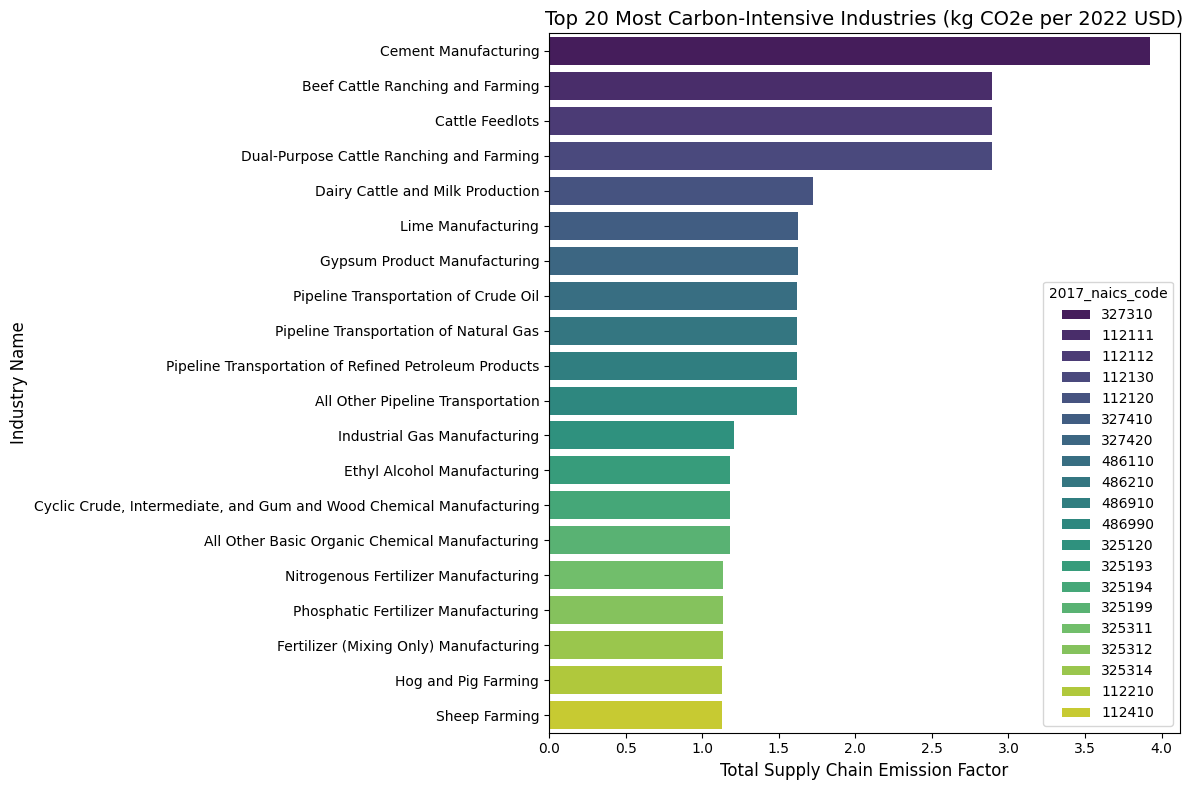

In [10]:
top_20 = df.nlargest(20, 'supply_chain_emission_factors_with_margins')

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_20,
    x='supply_chain_emission_factors_with_margins',
    y='2017_naics_title',
    hue = '2017_naics_code',
    legend='full',
    palette='viridis'
)
plt.title('Top 20 Most Carbon-Intensive Industries (kg CO2e per 2022 USD)', fontsize=14)
plt.xlabel('Total Supply Chain Emission Factor', fontsize=12)
plt.ylabel('Industry Name', fontsize=12)
plt.tight_layout()

Text(0.5, 0, 'kg CO2e per 2022 USD')

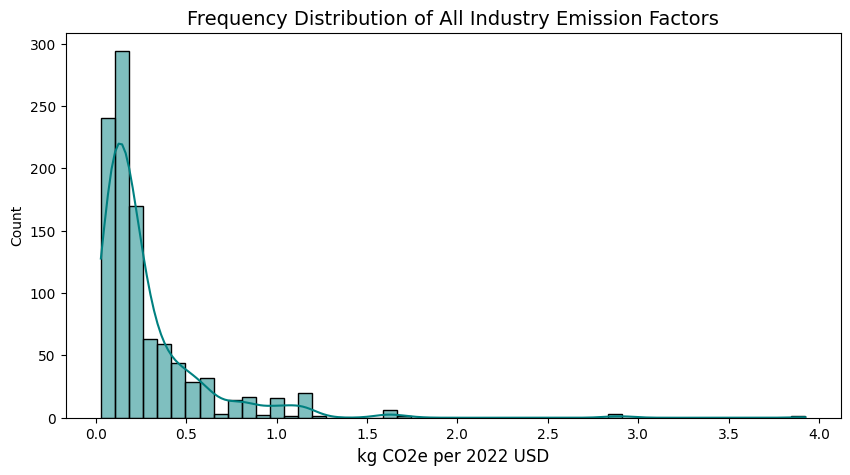

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['supply_chain_emission_factors_with_margins'], bins=50, kde=True, color='teal')
plt.title('Frequency Distribution of All Industry Emission Factors', fontsize=14)
plt.xlabel('kg CO2e per 2022 USD', fontsize=12)

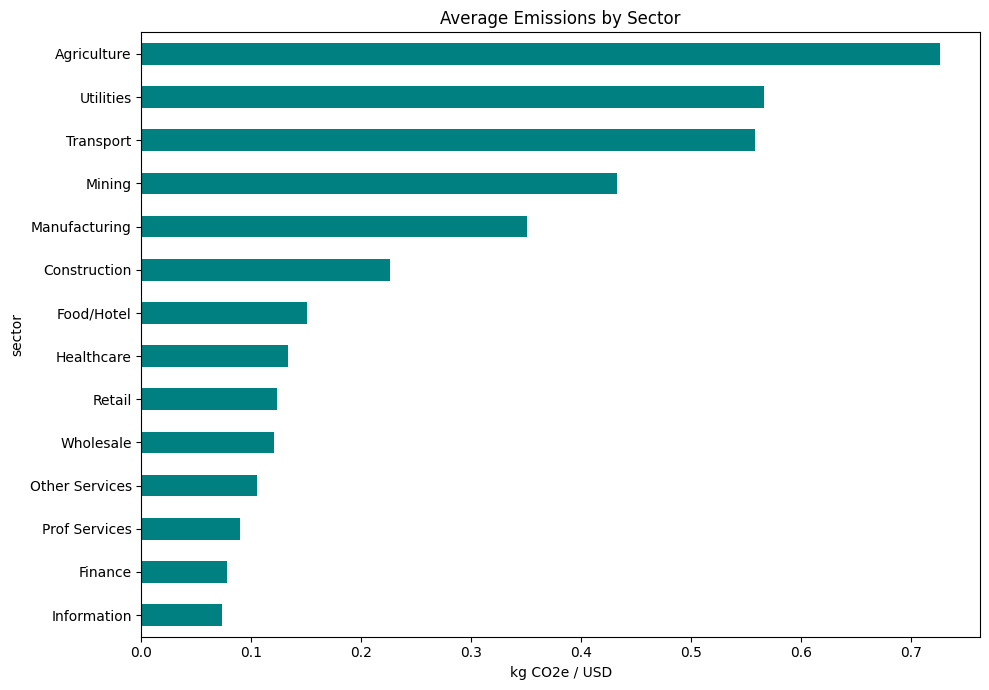

In [12]:
sector_map = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities', '23': 'Construction',
    '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
    '42': 'Wholesale', '44': 'Retail', '45': 'Retail', '48': 'Transport', 
    '51': 'Information', '52': 'Finance', '54': 'Prof Services', '62': 'Healthcare',
    '72': 'Food/Hotel', '81': 'Other Services'
}

(df.assign(sector=df['2017_naics_code'].astype(str).str[:2].map(sector_map))
   .groupby('sector')['supply_chain_emission_factors_with_margins'].mean()
   .sort_values()
   .plot(kind='barh', color='teal', figsize=(10, 7), title='Average Emissions by Sector'))

plt.xlabel('kg CO2e / USD')
plt.tight_layout()